# Libs

In [1]:
import argparse
import os
import sys
import time
import toml
import micmac
from tqdm import trange
import lineax as lx
from IPython.utils import io
import numpyro.distributions as dist

import time
from collections import namedtuple
from functools import partial
import matplotlib.pyplot as plt

import chex as chx
import healpy as hp
import jax
import jax.numpy as jnp
import jax.random as random
import numpy as np
import numpyro
import jax.lax as jlax
from jax import config
import jax.scipy as jsp
import jaxopt
import scipy as sp
import optax
from opt_einsum import contract

from micmac.noise.noisecovar import (
    get_BtinvN,
    get_inv_BtinvNB,
    get_inv_BtinvNB_c_ell,
    get_Wd,
    get_noise_covar_extended
)
from micmac.toolbox.statistics import get_1d_recursive_empirical_covariance

from micmac.toolbox.tools import (
    get_c_ells_from_red_covariance_matrix,
    get_cell_from_map_jax,
    get_reduced_matrix_from_c_ell,
    get_reduced_matrix_from_c_ell_jax,
    get_sqrt_reduced_matrix_from_matrix_jax,
    maps_x_red_covariance_cell_JAX,
    frequency_alms_x_obj_red_covariance_cell_JAX,
    get_stacked_red_covariance_matrix_from_c_ell_jax,
    component_maps_x_redcom_covariance_cell_JAX,
    transform_alms_shape,
    alm_dot_product_JAX,
    concatenate_frequency_stokes_alm,
    concatenate_reduced_multi_components_matrix,
    alms_x_red_covariance_cell_JAX,
)

from micmac.likelihood.sampling import (
    SamplingFunctions,
    multivariate_Metropolis_Hasting_step_numpyro_bounded_dictionary_sample,
    separate_single_MH_step_index_accelerated,
    separate_single_MH_step_index_v2b,
    separate_single_MH_step_index_v4_pixel,
    separate_single_MH_step_index_v4b_pixel,
    single_Metropolis_Hasting_step,
    single_LogNormal_Metropolis_Hasting_step,
    bounded_single_Metropolis_Hasting_step,
    multivariate_Metropolis_Hasting_step_numpyro_bounded,
    multivariate_Metropolis_Hasting_step
)


config.update('jax_enable_x64', True)

sys.path.append(os.path.dirname(os.path.abspath('')))

/home/tran/anaconda3/envs/micmac_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Run config

In [2]:
path_toml_params = "configs/icarus_test.toml"
with open(path_toml_params) as f:
    dictionary_parameters = toml.load(f)
f.close()
assert 'sampler_params' in dictionary_parameters
ICARUS_obj = micmac.create_IcarusSampler_from_dictionnary(dictionary_parameters['sampler_params'], path_file_spv='');

Loading or creating the spv config from a yaml file
No spatial variability case

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f0
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None

>>> Tree of spv config after filling the missing values:
root
  nside_spv
    default: [0]
    f0
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
      b4
        default: [0]
      b5
        default: [0]


In [3]:
add_seed_rank = 42
dictionary_run_configuration = dictionary_parameters['run_configuration']
seed_realization_input = dictionary_run_configuration['seed_realization_input']
instrument = micmac.get_instrument(ICARUS_obj.instrument_name)
    # Simulate CMB, foregrounds and noise maps 
fgs_model = dictionary_run_configuration['fgs_model']
print('Simulating input maps!', flush=True) 
np.random.seed(seed_realization_input+add_seed_rank)
freq_maps_fgs_denoised = micmac.get_observation(instrument, fgs_model, nside=ICARUS_obj.nside, noise=False)[
    :, 1:, :]


freq_maps_fgs_denoised = jax.vmap(ICARUS_obj.get_band_limited_maps, in_axes = 0, out_axes = 0)(freq_maps_fgs_denoised)
    
print(f"Setting up noise with seed {seed_realization_input+add_seed_rank}!", flush=True)

def gen_noise_map(seed_realization_input, add_seed_rank, instrument):
    np.random.seed(seed_realization_input+add_seed_rank)
    noise_map = micmac.get_noise_realization(ICARUS_obj.nside, instrument)[:, 1:, :]
    return noise_map
    
new_noise_map = gen_noise_map(seed_realization_input, add_seed_rank, instrument)
freq_maps_fgs = freq_maps_fgs_denoised + new_noise_map

print('Shape for input frequency maps :', freq_maps_fgs.shape)

r_true = dictionary_run_configuration['r_true']
print(f"Setting up CMB with seed {seed_realization_input + 1 +add_seed_rank}!", flush=True)
print(f"Simulating CMB with input r = {r_true}")

def gen_input_maps(r_true, seed_realization_input, add_seed_rank, freq_maps_fgs):
    seed_realization_CMB = seed_realization_input + 1

    np.random.seed(seed_realization_CMB+add_seed_rank)
    return ICARUS_obj.generate_input_freq_maps_from_fgs(freq_maps_fgs, 
                                                        r_true=r_true,
                                                        return_only_freq_maps=False)
    
input_freq_maps, input_cmb_maps, theoretical_red_cov_r0_total, theoretical_red_cov_r1_tensor = gen_input_maps(r_true, seed_realization_input, add_seed_rank, freq_maps_fgs)
theoretical_r0_total = micmac.get_c_ells_from_red_covariance_matrix(
    theoretical_red_cov_r0_total
) 
theoretical_r1_tensor = micmac.get_c_ells_from_red_covariance_matrix(
    theoretical_red_cov_r1_tensor
) 

# input_freq_maps_masked = input_freq_maps

Simulating input maps!
['d0']
Setting up noise with seed 84!
Shape for input frequency maps : (6, 2, 12288)
Setting up CMB with seed 85!
Simulating CMB with input r = 0.001
Calculating spectra from CAMB !
Calculating spectra from CAMB !


# Pixel CG test

In [4]:
nside = ICARUS_obj.nside
nstokes = ICARUS_obj.nstokes
lmin = ICARUS_obj.lmin
lmax = ICARUS_obj.lmax
n_iter = 3
n_components = 1#ICARUS_obj.n_components
n_frequencies = ICARUS_obj.n_frequencies
n_correlations = ICARUS_obj.n_correlations
n_pix = hp.nside2npix(nside)
foreground_maps_only = False
filedir = ""
mask_mode = "Planck" # "SO", "None"
list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_Planck_60_0_5_10_deg_no_pure.npy")
if mask_mode == "Planck":
    mask = hp.ud_grade(np.load(f"{filedir}masks/mask_60.npy"), nside_out = nside)
    phi_ang, theta_ang = hp.pix2ang(ICARUS_obj.nside, np.arange(mask.size), lonlat=True)
    mask[theta_ang>0] = 0
    list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_Planck_60_0_5_10_deg_no_pure.npy")
elif mask_mode == "SO":
    mask = hp.ud_grade(hp.read_map(f"{filedir}masks/mask_SO_SAT_apodized.fits", field = 0), nside_out = ICARUS_obj.nside)
    mask[mask > 0.3] = 1.0
    mask[mask < 0.3] = 0
    phi_ang, theta_ang = hp.pix2ang(ICARUS_obj.nside, np.arange(mask.size), lonlat=True)
    mask[theta_ang>0] = 0
    list_mode_coupling_mixing_matrices_nopure = np.load(f"{filedir}masks/mode_coupling_matrices_SO_SAT_0_5_10_deg_no_pure.npy")
else:
    mask = np.ones(hp.nside2npix(ICARUS_obj.nside))
    list_mode_coupling_mixing_matrices_nopure = np.eye(np.shape(list_mode_coupling_mixing_matrices_nopure)[0])
f_sky = np.mean(mask)
if dictionary_parameters['sampler_params']['instrument_name'] == "SO_SAT":
    A_dust = np.load(f"{filedir}fgs_params/dust_law_SO.npy")
    A_sync = np.load(f"{filedir}fgs_params/sync_law_SO.npy")
else:
    A_dust = np.load(f"{filedir}fgs_params/dust_law.npy")
    A_sync = np.load(f"{filedir}fgs_params/sync_law.npy")
B = np.ones((n_frequencies, n_components, n_pix))
if foreground_maps_only:
    B[:,0,:] = np.repeat(A_dust[...,np.newaxis], n_pix, axis = 1)
if n_components>1:
    B[:,1,:] = np.repeat(A_dust[...,np.newaxis], n_pix, axis = 1)
if n_components>2:
    B[:,2,:] = np.repeat(A_sync[...,np.newaxis], n_pix, axis = 1)
B = B*mask

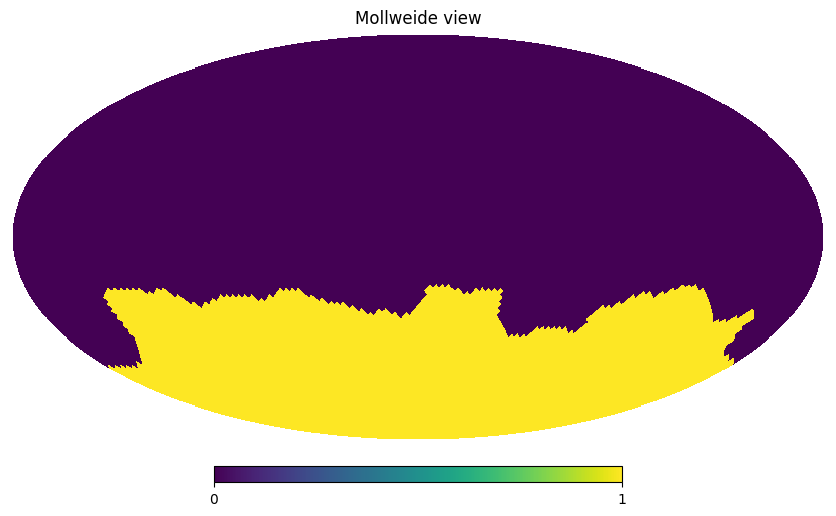

In [5]:
hp.mollview(mask)

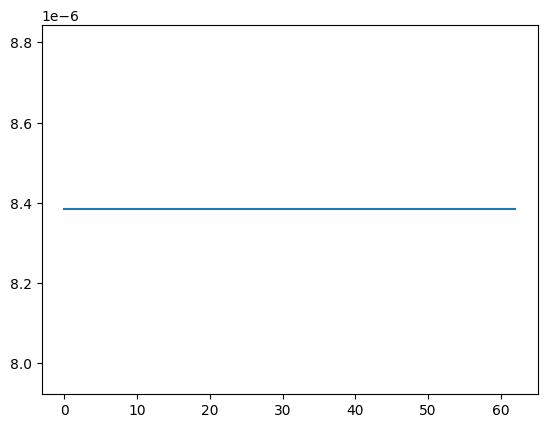

In [6]:
noise_factor = 1
depth_p = jnp.array(instrument["depth_p"])*noise_factor
noise_maps = new_noise_map*noise_factor
invN = get_noise_covar_extended(depth_p, nside)*mask

N_ell = micmac.noisecovar.get_Cl_noise_JAX(jnp.array(depth_p), np.mean(B, axis = 2), lmax = lmax)#*f_sky**2
# plt.plot(N_ell[0,0,2:])

# if f_sky < 1.:
#     coupling_correction = (
#         list_mode_coupling_mixing_matrices_nopure[0, 0::4, 0::4]
#     )[:lmax+1, :lmax+1]

#     coupling_correction = 0.5 * (
#         coupling_correction + coupling_correction.T
#     )

#     eigvals, eigvecs = jnp.linalg.eigh(coupling_correction)

#     eps = 1e-15 * jnp.max(eigvals)
#     safe_eigvals = jnp.where(eigvals > eps, eigvals, 1.0)

#     # Rotate to eigenbasis
#     N_rot = jnp.einsum("ij,...j->...i", eigvecs.T, N_ell)

#     # Apply M * N * M^{-1} in eigenbasis
#     N_rot = eigvals * N_rot / safe_eigvals

#     # Rotate back
#     N_ell = jnp.abs(jnp.einsum("ij,...j->...i", eigvecs, N_rot))
N_c_ell = micmac.noisecovar.get_true_Cl_noise(jnp.array(depth_p), lmax = lmax)
plt.plot(N_ell[0,0,2:])

In [7]:
d_temp_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_q_new.fits"), nside_out = ICARUS_obj.nside)
d_temp_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_u_new.fits"), nside_out = ICARUS_obj.nside)
S_dust = hp.anafast(np.vstack((jnp.ones_like(d_temp_Q),d_temp_Q, d_temp_U)*mask), lmax = ICARUS_obj.lmax)#/f_sky

s_temp_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_q_new.fits"), nside_out = ICARUS_obj.nside)
s_temp_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_u_new.fits"), nside_out = ICARUS_obj.nside)
S_sync = hp.anafast(np.vstack((jnp.ones_like(s_temp_Q),s_temp_Q, s_temp_U)*mask), lmax = ICARUS_obj.lmax)#/f_sky

# #---- Dust ----
# d_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_q_new.fits"), nside_out=nside)
# d_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/dust_u_new.fits"), nside_out=nside)

# # Q/U -> E/B
# _, d_E, d_B = hp.map2alm([np.zeros_like(d_Q), d_Q, d_U], lmax=lmax, pol=True)
# d_E = hp.alm2map(d_E, nside)
# d_B = hp.alm2map(d_B, nside)

# # Mask E/B
# d_E *= mask
# d_B *= mask

# # Spectra
# S_dust = hp.anafast([np.zeros_like(d_E), d_E, d_B], lmax=lmax) #/ f_sky


# # ---- Synchrotron ----
# s_Q = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_q_new.fits"), nside_out=nside)
# s_U = hp.ud_grade(hp.read_map(f"{filedir}fgs_params/synch_u_new.fits"), nside_out=nside)

# # Q/U -> E/B
# _, s_E, s_B = hp.map2alm([np.zeros_like(s_Q), s_Q, s_U], lmax=lmax, pol=True)
# s_E = hp.alm2map(s_E, nside)
# s_B = hp.alm2map(s_B, nside)

# # Mask E/B
# s_E *= mask
# s_B *= mask

# # Spectra
# S_sync = hp.anafast([np.zeros_like(s_E), s_E, s_B], lmax=lmax) #/ f_sky

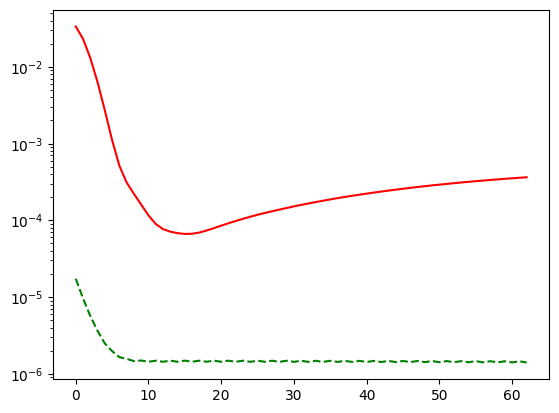

In [8]:
redcom_cov_matrix = jnp.zeros((lmax - lmin + 1,n_components, nstokes, n_components, nstokes))
if foreground_maps_only:
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,0].set(S_dust[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,1].set(S_dust[2,2:lmax+1])
    #redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,1].set(S_dust[4,2:lmax+1])
    #redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,0].set(S_dust[4,2:lmax+1])
else:
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,0,0,0].set(theoretical_red_cov_r0_total[:,0,0])
    redcom_cov_matrix = redcom_cov_matrix.at[:,0,1,0,1].set(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true)
if n_components > 1:
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,0,1,0].set(S_dust[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,1,1,1].set(S_dust[2,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,0,1,1].set(S_dust[4,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,1,1,1,0].set(S_dust[4,2:lmax+1])
if n_components > 2:
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,0,2,0].set(S_sync[1,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,1,2,1].set(S_sync[2,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,0,2,1].set(S_sync[4,2:lmax+1])
    redcom_cov_matrix = redcom_cov_matrix.at[:,2,1,2,0].set(S_sync[4,2:lmax+1])
redcom_cov_matrix_sqrt = sp.linalg.sqrtm(redcom_cov_matrix.reshape(lmax - lmin + 1, 
                                                                         n_components*nstokes, 
                                                                         n_components*nstokes)).reshape(lmax - lmin + 1, 
                                                                                                        n_components, nstokes, 
                                                                                                        n_components, nstokes)
redcom_cov_matrix_sqrt = jnp.array(redcom_cov_matrix_sqrt)
plt.plot(theoretical_red_cov_r0_total[:,0,0]+theoretical_red_cov_r1_tensor[:,0,0]*r_true, "r-")
plt.plot(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true, "g--")
#plt.plot(S3_BB, "b--")
plt.yscale("log")


In [9]:
if n_components > 1:
    d = (input_cmb_maps + noise_maps + freq_maps_fgs_denoised)*mask
elif foreground_maps_only:
    d = (noise_maps + freq_maps_fgs_denoised)*mask
else:
    d = (input_cmb_maps + noise_maps)*mask
d = jax.vmap(ICARUS_obj.get_band_limited_maps, in_axes = 0, out_axes = 0)(d)

In [10]:
#invN_sqrt = sp.linalg.sqrtm(invN.transpose(2,0,1)).transpose(1,2,0)
invN_sqrt = jnp.sqrt(invN.transpose(2,0,1)).transpose(1,2,0)
invBtinvNB = micmac.noisecovar.get_inv_BtinvNB(invN, B)
BtinvN_sqrt = get_BtinvN(invN_sqrt, B)
#mask = jnp.ones(hp.nside2npix(nside))
redcom_N = jnp.einsum('cdp,sk->pcsdk',invBtinvNB, np.eye(nstokes))
#redcom_N = jnp.einsum('cdp,sk->pcsdk',invBtinvNB, np.eye(nstokes))
print(redcom_N.shape)
redcom_N_inv = jnp.copy(redcom_N)
redcom_N_inv = redcom_N_inv.at[mask != 0].set(jnp.linalg.pinv(redcom_N.reshape(n_pix, n_components*nstokes, n_components*nstokes)).reshape(n_pix, n_components, nstokes, n_components, nstokes)[mask!=0])

(12288, 1, 2, 1, 2)


In [11]:
s_ML = jnp.einsum('cg...,hg...,hf...,f...->c...', invBtinvNB, B, invN, d)

In [12]:
# inv_redcom_cov_matrix = jnp.linalg.pinv(redcom_cov_matrix.reshape(lmax - lmin + 1, 
#                                                                          n_components*nstokes, 
#                                                                          n_components*nstokes)).reshape(lmax - lmin + 1, 
#                                                                                                         n_components, nstokes, 
#                                                                                                         n_components, nstokes)
# inv_redcom_cov_matrix
redcom_N_ell = jnp.einsum('cdl,sk->lcsdk',N_ell[...,lmin::], np.eye(nstokes))
inv_redcom_N_ell = jnp.linalg.pinv(redcom_N_ell.reshape(lmax - lmin + 1, 
                                                     n_components*nstokes, 
                                                     n_components*nstokes)).reshape(lmax - lmin + 1, 
                                                                                    n_components, nstokes, 
                                                                                    n_components, nstokes)

redcom_preconditioner_s = jnp.linalg.pinv(
    jnp.eye(n_components*nstokes)
    + jnp.einsum('labcd,lcdef,lefgh->labgh', redcom_cov_matrix_sqrt, inv_redcom_N_ell, redcom_cov_matrix_sqrt).reshape(lmax - lmin + 1, 
                                                     n_components*nstokes, 
                                                     n_components*nstokes),
).reshape(lmax - lmin + 1, 
            n_components, nstokes, 
            n_components, nstokes)

# inner_term_redcom_preconditioner_s_2 = jnp.linalg.pinv(
#     (inv_redcom_cov_matrix
#     + inv_redcom_N_ell).reshape(lmax - lmin + 1, 
#                                 n_components*nstokes, 
#                                 n_components*nstokes) #/  f_sky ** 2 
# ).reshape(lmax - lmin + 1, 
#             n_components, nstokes, 
#             n_components, nstokes) #*  f_sky 
# inv_redcom_cov_matrix_sqrt = jnp.linalg.pinv((redcom_cov_matrix_sqrt).reshape(lmax - lmin + 1, 
#                                                      n_components*nstokes, 
#                                                      n_components*nstokes)).reshape(lmax - lmin + 1, 
#             n_components, nstokes, 
#             n_components, nstokes) #/  f_sky ** 2 
# redcom_preconditioner_s_2 =  jnp.einsum('labcd,lcdef,lefgh->labgh', inv_redcom_cov_matrix_sqrt, inner_term_redcom_preconditioner_s_2, inv_redcom_cov_matrix_sqrt)

precond_func = lambda x: component_maps_x_redcom_covariance_cell_JAX(
    x.reshape((n_components, nstokes, n_pix)),
    redcom_preconditioner_s,
    nside=nside,
    lmin=lmin,
    n_iter=n_iter,
).ravel()

In [13]:
# Initial guess for the CG

max_iter_CG = 10000 #400
limit_iter_cg = 10000
tolerance_CG = 1e-6
initial_guess=jnp.empty(0)
if jnp.size(initial_guess) == 0:
    initial_guess = jnp.zeros_like(s_ML)
options = dict()
options['y0'] = jnp.zeros_like(initial_guess.ravel())
options['preconditioner'] = lx.FunctionLinearOperator(precond_func, input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_pix,),jnp.float64), tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))

In [14]:
# Preparation of the harmonic operator C^{1/2} for the LHS of the CG
first_part_term_left = lambda x: component_maps_x_redcom_covariance_cell_JAX(
    x.reshape((n_components, nstokes, n_pix)),
    redcom_cov_matrix_sqrt,
    nside=nside,
    lmin=lmin,
    n_iter=n_iter,
).ravel()

## Second left member pixel operator: (E^t (B^t N^{-1} B)^{-1} E) x
def second_part_term_left(x):
    return jnp.einsum(
        'csp, pekcs -> ekp', x.reshape((n_components, nstokes, n_pix)), redcom_N_inv/hp.nside2resol(nside)**2
    ).ravel()

# Full operator to inverse: Id + C^{1/2} N_c^{-1} C^{1/2}
func_left_term = lambda x: x + first_part_term_left(second_part_term_left(first_part_term_left(x)))



func_lineax = lx.FunctionLinearOperator(func_left_term,
                                        input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_pix,),jnp.float64), 
                                        tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))

solver = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm,)
throw = False

## s_WF 

In [15]:
invNsML = jnp.einsum('csp, pekcs -> ekp', s_ML, redcom_N_inv)
right_member_WF = component_maps_x_redcom_covariance_cell_JAX(
    invNsML/hp.nside2resol(nside)**2, redcom_cov_matrix_sqrt, nside=nside, lmin=lmin, n_iter=n_iter
)
t = time.time()
solution = lx.linear_solve(func_lineax, right_member_WF.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_pix))

wiener_filter_term = component_maps_x_redcom_covariance_cell_JAX(
    result_lineax,
    redcom_cov_matrix_sqrt,
    nside=nside,
    lmin=lmin,
    n_iter=n_iter,
)
s_WF = wiener_filter_term.reshape((n_components, nstokes, n_pix))
print(time.time() - t)

solved in 914 steps
18.1001033782959


## Fluctuations

In [16]:
jax_key_PNRG = random.PRNGKey(42)

map_random_realization_xi=None 
map_random_realization_chi=None 
initial_guess=jnp.empty(0) 

jax_key_PNRG, jax_key_PNRG_xi = random.split(jax_key_PNRG)  # Splitting of the random key to generate a new one

# Creation of the random maps if they are not given
if map_random_realization_xi is None:
    # If no random maps are provided, then it is computed within the routine
    print('Recalculating xi !')
    map_random_realization_xi = jax.random.normal(
        jax_key_PNRG_xi, shape=(n_components, nstokes, n_pix)
    ) / hp.nside2resol(nside)

jax_key_PNRG, *jax_key_PNRG_chi = random.split(
    jax_key_PNRG, n_frequencies + 1
)  # Splitting of the random key to generate a new one
if map_random_realization_chi is None:
    # If no random maps are provided, then it is computed within the routine
    print('Recalculating chi !')

    def fmap(random_key):
        random_map = jax.random.normal(random_key, shape=(nstokes, n_pix))
        # return get_band_limited_maps(random_map)
        return random_map

    map_random_realization_chi = jax.vmap(fmap)(
        jnp.array(jax_key_PNRG_chi)
    ) / hp.nside2resol(nside) # Generating a different random Gaussian map for each frequency

    chx.assert_shape(map_random_realization_chi, (n_frequencies, nstokes, n_pix))

# Computation of the right side member of the CG

# First right member: xi
right_member_1 = map_random_realization_xi
# Second right member:

## Computation of \chi term = S^{1/2} B^t N^{-1/2} \chi
# First compute B^t N^{-1/2} \chi
right_member_2_part = jnp.einsum('cfp,fsp->csp', BtinvN_sqrt/hp.nside2resol(nside), map_random_realization_chi)

# Then apply S^{1/2} to B^t N^{-1/2} \chi
right_member_2 = component_maps_x_redcom_covariance_cell_JAX(
    right_member_2_part, redcom_cov_matrix_sqrt, nside=nside, lmin=lmin, n_iter=n_iter
)

right_member_fluct = (jax.vmap(ICARUS_obj.get_band_limited_maps)(right_member_1)) + right_member_2
# Computation of the left side member of the equation

t = time.time()
solution = lx.linear_solve(func_lineax, right_member_fluct.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_pix))

fluctuating_map = component_maps_x_redcom_covariance_cell_JAX(
    result_lineax,
    redcom_cov_matrix_sqrt,
    nside=nside,
    lmin=lmin,
    n_iter=n_iter,
)
zeta = fluctuating_map.reshape((n_components, nstokes, n_pix))
print(time.time() - t)

Recalculating xi !
Recalculating chi !
solved in 1101 steps
22.21765375137329


## Combined

In [17]:
t = time.time()
solution = lx.linear_solve(func_lineax, right_member_WF.ravel()+right_member_fluct.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_pix))

combined_map = component_maps_x_redcom_covariance_cell_JAX(
    result_lineax,
    redcom_cov_matrix_sqrt,
    nside=nside,
    lmin=lmin,
    n_iter=n_iter,
)
combined = combined_map.reshape((n_components, nstokes, n_pix))
print(time.time() - t)

solved in 927 steps
18.525771379470825


## Check spectra

Text(0.5, 1.0, 'BB')

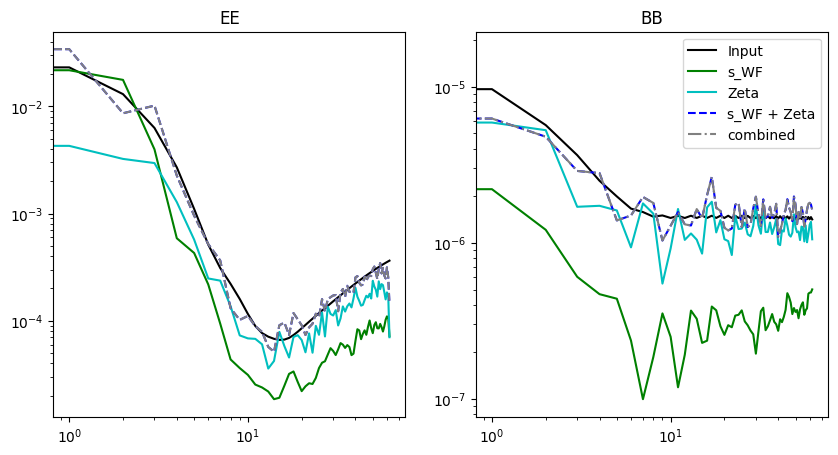

In [18]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
#zeta = np.zeros_like(s_WF)
s_ML_CMB = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_ML[0,:,:]))
s_WF_CMB = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_WF[0,:,:]))
zeta_CMB = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),zeta[0,:,:]))
combined_CMB = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),combined_map[0,:,:]))

ax[0].plot(theoretical_red_cov_r0_total[:,0,0], "k")
ax[0].plot(hp.anafast(s_WF_CMB, lmax = ICARUS_obj.lmax)[1,lmin::], "g")
ax[0].plot(hp.anafast(zeta_CMB, lmax = ICARUS_obj.lmax)[1,lmin::], "c")
ax[0].plot(hp.anafast(s_WF_CMB + zeta_CMB, lmax = ICARUS_obj.lmax)[1,lmin::], "b--")
ax[0].plot(hp.anafast(combined_CMB, lmax = ICARUS_obj.lmax)[1,lmin::], linestyle = "--", color = "grey")

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].set_title("EE")

ax[1].plot(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true, "k", label = "Input")
ax[1].plot(hp.anafast(s_WF_CMB, lmax = ICARUS_obj.lmax)[2,2::], "g", label = "s_WF")
ax[1].plot(hp.anafast(zeta_CMB, lmax = ICARUS_obj.lmax)[2,2::], "c", label = "Zeta")
ax[1].plot(hp.anafast(s_WF_CMB + zeta_CMB, lmax = ICARUS_obj.lmax)[2,2::], "b--", label = "s_WF + Zeta")
ax[1].plot(hp.anafast(combined_CMB, lmax = ICARUS_obj.lmax)[2,lmin::], linestyle = "-.", color = "grey", label = "combined")

ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_title("BB")

Text(0.5, 1.0, 'BB')

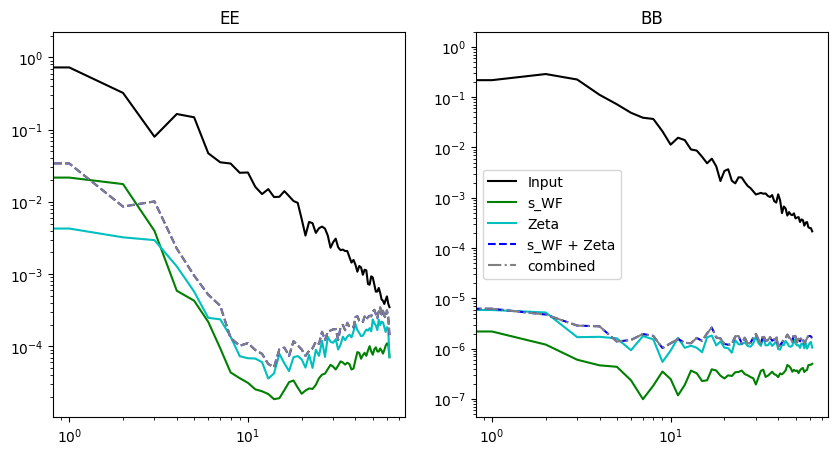

In [19]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
#zeta = np.zeros_like(s_WF)
s_ML_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_ML[1,:,:]))
s_WF_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_WF[1,:,:]))
zeta_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),zeta[1,:,:]))
combined_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),combined_map[1,:,:]))

ax[0].plot(S_dust[1,lmin:], "k")
ax[0].plot(hp.anafast(s_WF_fgs, lmax = ICARUS_obj.lmax)[1,lmin::], "g")
ax[0].plot(hp.anafast(zeta_fgs, lmax = ICARUS_obj.lmax)[1,lmin::], "c")
ax[0].plot(hp.anafast(s_WF_fgs + zeta_fgs, lmax = ICARUS_obj.lmax)[1,lmin::], "b--")
ax[0].plot(hp.anafast(combined_fgs, lmax = ICARUS_obj.lmax)[1,lmin::], linestyle = "--", color = "grey")

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].set_title("EE")

ax[1].plot(S_dust[2,lmin:], "k", label = "Input")
ax[1].plot(hp.anafast(s_WF_fgs, lmax = ICARUS_obj.lmax)[2,2::], "g", label = "s_WF")
ax[1].plot(hp.anafast(zeta_fgs, lmax = ICARUS_obj.lmax)[2,2::], "c", label = "Zeta")
ax[1].plot(hp.anafast(s_WF_fgs + zeta_fgs, lmax = ICARUS_obj.lmax)[2,2::], "b--", label = "s_WF + Zeta")
ax[1].plot(hp.anafast(combined_fgs, lmax = ICARUS_obj.lmax)[2,lmin::], linestyle = "-.", color = "grey", label = "combined")

ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_title("BB")

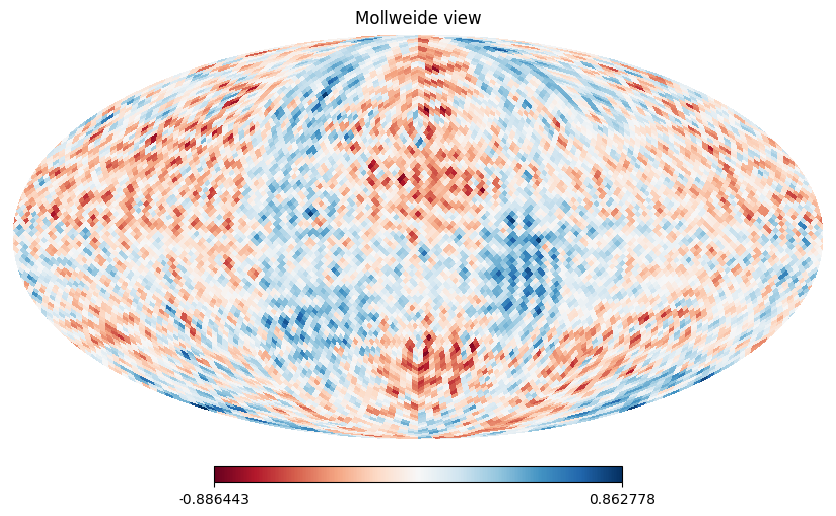

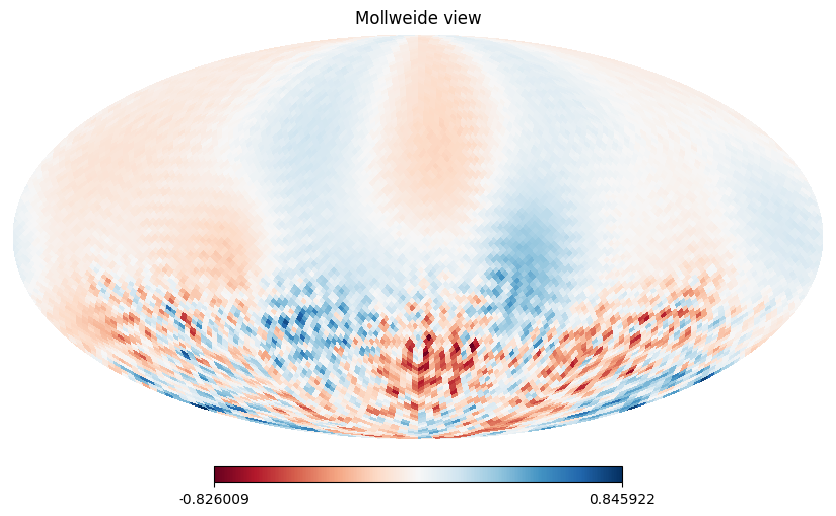

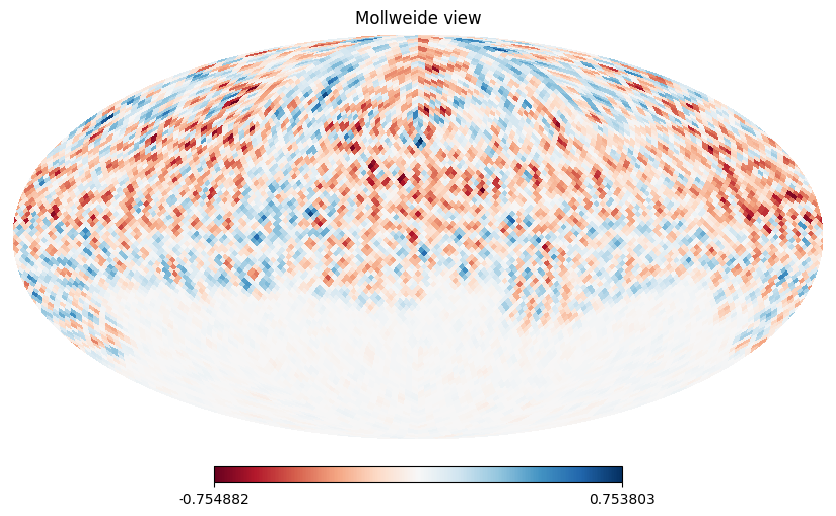

In [20]:
hp.mollview(combined[0,0,:], cmap = "RdBu")
hp.mollview(s_WF[0,0,:], cmap = "RdBu")
hp.mollview(zeta[0,0,:], cmap = "RdBu")

# Alms CG test

## High iter alm2map

In [21]:
# Wrapper for map2alm, to prepare the pure callback of JAX
n_iter = 10
def wrapper_map2alm(maps_, lmax=lmax, n_iter=n_iter, nside=nside):
    maps_np = jax.tree.map(np.asarray, maps_).reshape((3, 12 * nside**2))
    alm_T, alm_E, alm_B = hp.map2alm(maps_np, lmax=lmax, iter=n_iter)
    return np.array([alm_T, alm_E, alm_B])

# Wrapper for alm2map, to prepare the pure callback of JAX
def wrapper_alm2map(alm_, lmax=lmax, nside=nside):
    if alm_.shape[0] != 3:
        alm_ = jnp.vstack((jnp.zeros(((3 - alm_.shape[0]), alm_.shape[1])), alm_))
    alm_np = jax.tree.map(np.asarray, alm_)
    return hp.alm2map(alm_np, nside, lmax=lmax)

# Pure call back of map2alm, to be used with JAX for JIT compilation
@partial(jax.jit, static_argnums=(1, 2))
def pure_call_map2alm(maps_, lmax=lmax, nside=nside):
    shape_output = (3, (lmax + 1) * (lmax // 2 + 1))
    return jax.pure_callback(
        wrapper_map2alm,
        jax.ShapeDtypeStruct(shape_output, np.complex128),
        maps_.ravel(),
    )

@partial(jax.jit)
def pure_call_alm2map(alm_):
    shape_output = (3, 12 * nside**2)
    return jax.pure_callback(wrapper_alm2map, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

## Right member alms

In [22]:
right_member_unravel = right_member_WF + right_member_fluct
right_member_alms = jax.vmap(pure_call_map2alm)(np.concatenate((jnp.zeros_like(right_member_unravel[:, 0][:, None, ...]),right_member_unravel), axis = 1))[
    :, 3 - nstokes :, ...
]
n_lms = (ICARUS_obj.lmax + 1) * (ICARUS_obj.lmax // 2 + 1)

In [23]:
def frequency_almxfl_2D(alms, fl, lmax, lmin):
    assert fl.shape[0] == lmax - lmin + 1
    assert alms.shape[-1] == (lmax + 1)*(lmax//2 + 1)
    assert alms.shape[0] == fl.shape[1]
    assert alms.shape[1] == fl.shape[2]
    alms_2D = transform_alms_shape(alms, lmax = lmax, transformation = "healpix_to_2dlm")
    zero_pad = jnp.repeat(jnp.zeros_like(alms_2D[:,:,0,:])[:,:,np.newaxis,:], 2, axis = 2)
    alms_2D_result = jnp.concatenate((zero_pad, jnp.einsum("fsLm, Lfset -> etLm", alms_2D[..., lmin:, :], fl)), axis = 2)
    alms_result = transform_alms_shape(alms_2D_result, lmax = lmax, transformation = "2dlm_to_healpix")
    return alms_result

In [24]:
frequency_almxfl_2D(right_member_alms, redcom_cov_matrix_sqrt, lmax = lmax, lmin = lmin)
#frequency_almxfl_1D(right_member_alms, redcom_cov_matrix_sqrt, lmax = lmax, lmin = lmin)

Array([[[ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          5.42616265e+02+0.00000000e+00j, ...,
          2.50178160e-02+2.18116012e-02j,
         -3.56546973e-02-3.49710129e-02j,
          3.24563891e-02+7.52836805e-03j],
        [ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          6.74205537e-02+0.00000000e+00j, ...,
          1.11150803e-03+1.03596173e-03j,
         -4.11016526e-04+5.06286068e-04j,
          6.85916439e-04+7.52118069e-05j]]], dtype=complex128)

In [25]:
def component_alms_x_redcom_covariance_pixel_JAX(component_alms, redcom_pixel_covariance, nside, lmax, n_iter=3):
    """
    Return alms convolved with the pixel covariance matrix given as input
    in the format [n_pix, n_components, nstokes, n_components, nstokes], assuming it's block diagonal

    The input matrix have to start from ell=lmin, otherwise the lmax associated with the harmonic
    operations will be wrong

    Parameters
    ----------
    component_alms: array[float] of shape [n_components, nstokes, n_alms]
         input maps
    red_matrix_sqrt: array[float] of shape [n_pix, n_components, nstokes, n_components, nstokes]
        input reduced spectra
    nside: int
        nside of the input maps
    lmax: int
        maximum ell for the spectrum
    n_iter: int
        number of iterations for harmonic operations

    Returns
    -------
    maps_output: array[float] of shape [n_components, nstokes, n_alms]
        input maps convolved with input spectra
    """
    n_components = component_alms.shape[0]
    nstokes = component_alms.shape[1]

    # Wrapper for map2alm, to prepare the pure callback of JAX
    def wrapper_map2alm(maps_, lmax=lmax, n_iter=n_iter, nside=nside):
        maps_np = jax.tree.map(np.asarray, maps_).reshape((3, 12 * nside**2))
        alm_T, alm_E, alm_B = hp.map2alm(maps_np, lmax=lmax, iter=n_iter)
        return np.array([alm_T, alm_E, alm_B])
    
    # Wrapper for alm2map, to prepare the pure callback of JAX
    def wrapper_alm2map(alm_, lmax=lmax, nside=nside):
        if alm_.shape[0] != 3:
            alm_ = jnp.vstack((jnp.zeros(((3 - alm_.shape[0]), alm_.shape[1])), alm_))
        alm_np = jax.tree.map(np.asarray, alm_)
        return hp.alm2map(alm_np, nside, lmax=lmax)
    
    # Pure call back of map2alm, to be used with JAX for JIT compilation
    @partial(jax.jit, static_argnums=(1, 2))
    def pure_call_map2alm(maps_, lmax=lmax, nside=nside):
        shape_output = (3, (lmax + 1) * (lmax // 2 + 1))
        return jax.pure_callback(
            wrapper_map2alm,
            jax.ShapeDtypeStruct(shape_output, np.complex128),
            maps_.ravel(),
        )
    
    @partial(jax.jit)
    def pure_call_alm2map(alm_):
        shape_output = (3, 12 * nside**2)
        return jax.pure_callback(wrapper_alm2map, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

    if component_alms.shape[1] == 2:
        component_alms_TEB = jnp.concatenate(
            (jnp.zeros_like(component_alms[:, 0][:, None, ...]), jnp.copy(component_alms[:, ...])), axis=1
        )
    else:
        component_alms_TEB = jnp.copy(component_alms)
    component_maps_QU = jax.vmap(pure_call_alm2map)(component_alms_TEB)[
        :, 3 - nstokes :, ...
        ]
    maps_output = jnp.einsum('csp, pekcs -> ekp', component_maps_QU, redcom_pixel_covariance)

    alms_output = jax.vmap(pure_call_map2alm)(jnp.concatenate((jnp.zeros_like(maps_output[:, 0][:, None, ...]),maps_output), axis = 1))[
        :, 3 - nstokes :, ...]
    return alms_output

In [26]:
## Second left member pixel operator: (E^t (B^t N^{-1} B)^{-1} E) x
first_part_term_left_alms = lambda x: frequency_almxfl_2D(
    x.reshape((n_components, nstokes, n_lms)),
    redcom_cov_matrix_sqrt,
    lmax = lmax,
    lmin = lmin,
).ravel()

def second_part_term_left_alms(x):
    return component_alms_x_redcom_covariance_pixel_JAX(
        x.reshape((n_components, nstokes, n_lms)), 
        redcom_N_inv/hp.nside2resol(nside)**2,
        nside = nside,
        lmax = lmax,
    ).ravel()

# Full operator to inverse: Id + C^{1/2} N_c^{-1} C^{1/2}

func_left_term_alms = lambda x: x + first_part_term_left_alms(second_part_term_left_alms(first_part_term_left_alms(x)))

In [27]:
precond_func_alms = lambda x: frequency_almxfl_2D(
    x.reshape((n_components, nstokes, n_lms)),
    redcom_preconditioner_s,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
).ravel()

In [28]:
initial_guess = jnp.zeros_like(right_member_alms)
max_iter_CG = 10000 #400
limit_iter_cg = 10000
tolerance_CG = 1e-6
options = dict()
options['y0'] = jnp.zeros_like(initial_guess.ravel())
options['preconditioner'] = lx.FunctionLinearOperator(precond_func_alms, input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_lms,),jnp.complex128), tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))
func_lineax = lx.FunctionLinearOperator(func_left_term_alms, input_structure=jax.ShapeDtypeStruct((n_components*nstokes*n_lms,),jnp.complex128), tags=(lx.positive_semidefinite_tag, lx.symmetric_tag))

solver = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm,)
throw = False

t = time.time()
solution = lx.linear_solve(func_lineax, right_member_alms.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((n_components, nstokes, n_lms))

combined_alms_z = frequency_almxfl_2D(
    result_lineax,
    redcom_cov_matrix_sqrt,
    lmax = ICARUS_obj.lmax,
    lmin = ICARUS_obj.lmin,
)
combined_alms = combined_alms_z.reshape((n_components, nstokes, n_lms))
print(time.time() - t)

solved in 10000 steps
43.345829010009766


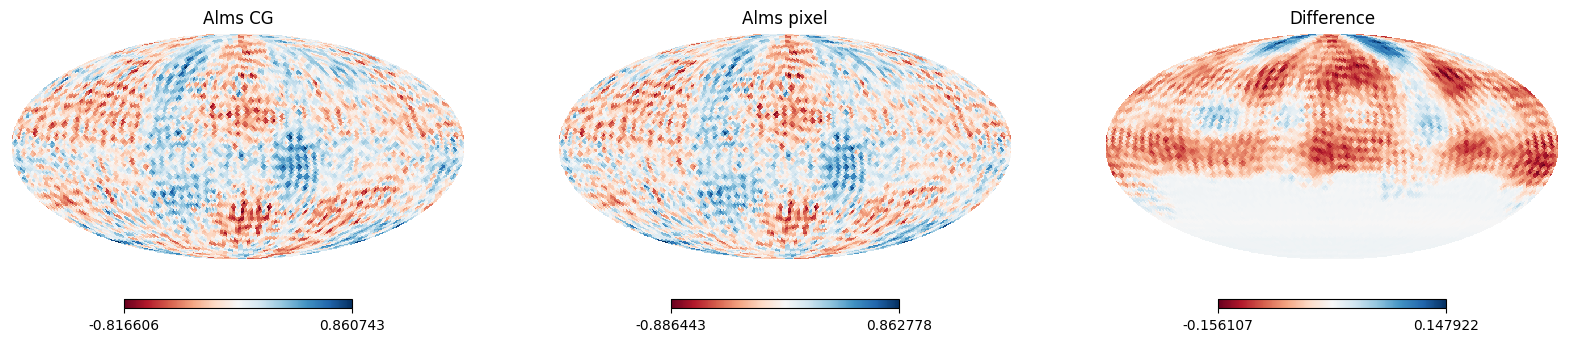

In [29]:
maps_from_alms_CG = hp.alm2map(np.concatenate((np.zeros_like(combined_alms[0,0,:])[np.newaxis,:], combined_alms[0])), nside = nside)
fig, ax = plt.subplots(1,3, figsize = (20,10))
plt.axes(ax[0])
hp.mollview(maps_from_alms_CG[1], cmap = "RdBu", hold = True, title = "Alms CG")
plt.axes(ax[1])
hp.mollview(combined[0,0,:], cmap = "RdBu",  hold = True, title = "Alms pixel")
plt.axes(ax[2])
hp.mollview(combined[0,0,:] - maps_from_alms_CG[1], cmap = "RdBu",  hold = True, title = "Difference")

Text(0.5, 1.0, 'BB')

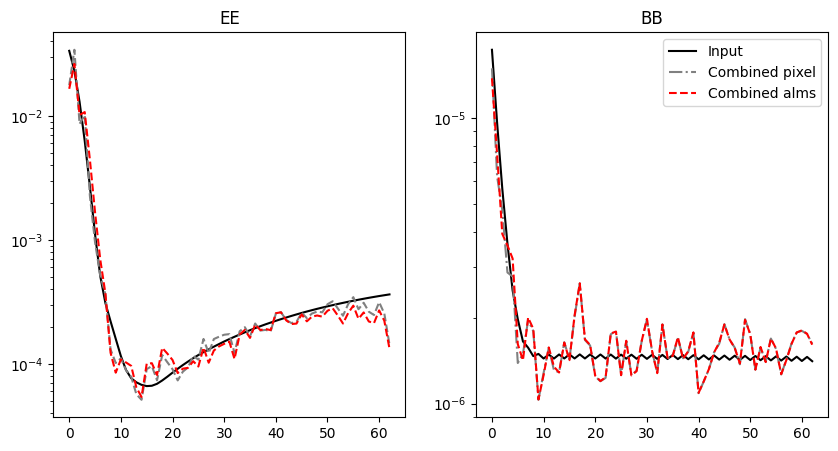

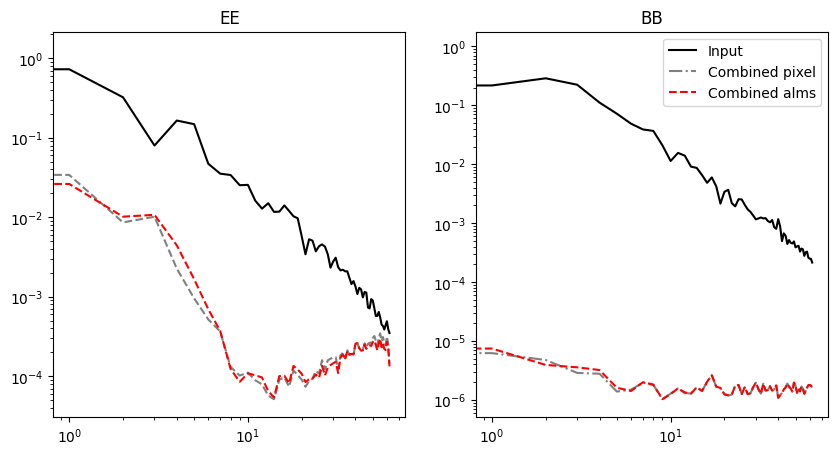

In [30]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
#zeta = np.zeros_like(s_WF)

ax[0].plot(theoretical_red_cov_r0_total[:,0,0], "k")
ax[0].plot(hp.anafast(combined_CMB, lmax = ICARUS_obj.lmax)[1,lmin::], linestyle = "--", color = "grey")
ax[0].plot(hp.alm2cl(np.concatenate((np.zeros_like(combined_alms[0,0,:])[np.newaxis,:], combined_alms[0])), lmax = lmax)[1, 2:], "r--")
ax[0].set_yscale("log")
#ax[0].set_xscale("log")
ax[0].set_title("EE")

ax[1].plot(theoretical_red_cov_r0_total[:,1,1]+theoretical_red_cov_r1_tensor[:,1,1]*r_true, "k", label = "Input")
ax[1].plot(hp.anafast(combined_CMB, lmax = ICARUS_obj.lmax)[2,lmin::], linestyle = "-.", color = "grey", label = "Combined pixel")
ax[1].plot(hp.alm2cl(np.concatenate((np.zeros_like(combined_alms[0,0,:])[np.newaxis,:], combined_alms[0])), lmax = lmax)[2, 2:], "r--", label = "Combined alms")
ax[1].legend()
ax[1].set_yscale("log")
#ax[1].set_xscale("log")
ax[1].set_title("BB")

fig, ax = plt.subplots(1,2, figsize = (10,5))
#zeta = np.zeros_like(s_WF)
s_ML_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_ML[1,:,:]))
s_WF_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),s_WF[1,:,:]))
zeta_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),zeta[1,:,:]))
combined_fgs = np.vstack((np.ones(hp.nside2npix(ICARUS_obj.nside)),combined_map[1,:,:]))

ax[0].plot(S_dust[1,lmin:], "k")
ax[0].plot(hp.anafast(combined_fgs, lmax = ICARUS_obj.lmax)[1,lmin::], linestyle = "--", color = "grey")
ax[0].plot(hp.alm2cl(np.concatenate((np.zeros_like(combined_alms[0,0,:])[np.newaxis,:], combined_alms[1])), lmax = lmax)[1, 2:], "r--")

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].set_title("EE")

ax[1].plot(S_dust[2,lmin:], "k", label = "Input")
ax[1].plot(hp.anafast(combined_fgs, lmax = ICARUS_obj.lmax)[2,lmin::], linestyle = "-.", color = "grey", label = "Combined pixel")
ax[1].plot(hp.alm2cl(np.concatenate((np.zeros_like(combined_alms[0,0,:])[np.newaxis,:], combined_alms[1])), lmax = lmax)[2, 2:], "r--",  label = "Combined alms")

ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_title("BB")

# Checking for differences

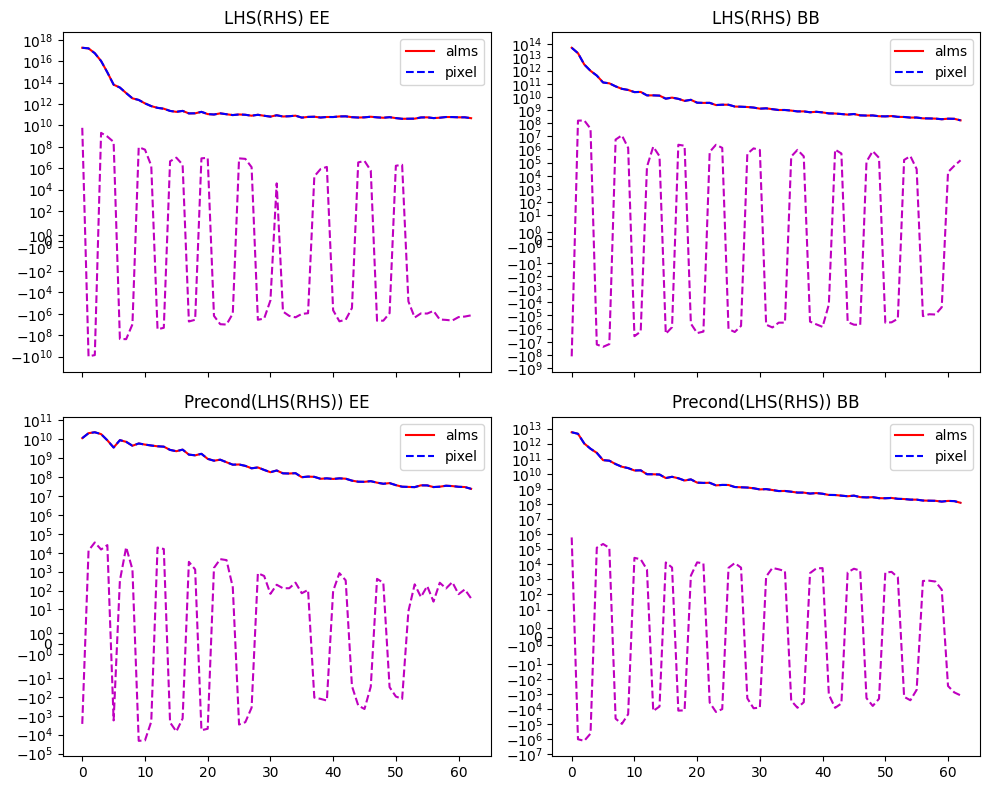

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

# ---------- LHS(RHS) ----------
test_alms = func_left_term_alms(right_member_alms.ravel()).reshape((n_components, nstokes, n_lms))
test_pixel = func_left_term(right_member_WF.ravel() + right_member_fluct.ravel()).reshape((n_components, nstokes, n_pix))

cl_alms = hp.alm2cl(
    np.concatenate((np.zeros_like(test_alms[0,0,:])[np.newaxis,:], test_alms[0])),
    lmax=lmax
)
cl_pix = hp.anafast(
    np.concatenate((np.zeros_like(test_pixel[0,0,:])[np.newaxis,:], test_pixel[0])),
    lmax=lmax
)

# EE (col 0)
axs[0, 0].plot(cl_alms[1, 2:], "r-", label="alms")
axs[0, 0].plot(cl_pix[1, 2:], "b--", label="pixel")
axs[0, 0].plot(cl_alms[1, 2:] - cl_pix[1, 2:], "m--")
axs[0, 0].set_title("LHS(RHS) EE")
axs[0, 0].set_yscale("symlog")
axs[0, 0].legend()

# BB (col 1)
axs[0, 1].plot(cl_alms[2, 2:], "r-", label="alms")
axs[0, 1].plot(cl_pix[2, 2:], "b--", label="pixel")
axs[0, 1].plot(cl_alms[2, 2:] - cl_pix[2, 2:], "m--")
axs[0, 1].set_title("LHS(RHS) BB")
axs[0, 1].set_yscale("symlog")
axs[0, 1].legend()


# ---------- Preconditioned ----------
test_alms = precond_func_alms(func_left_term_alms(right_member_alms.ravel())).reshape((n_components, nstokes, n_lms))
test_pixel = precond_func(func_left_term(right_member_WF.ravel() + right_member_fluct.ravel())).reshape((n_components, nstokes, n_pix))

cl_alms = hp.alm2cl(
    np.concatenate((np.zeros_like(test_alms[0,0,:])[np.newaxis,:], test_alms[0])),
    lmax=lmax
)
cl_pix = hp.anafast(
    np.concatenate((np.zeros_like(test_pixel[0,0,:])[np.newaxis,:], test_pixel[0])),
    lmax=lmax
)

# EE (col 0)
axs[1, 0].plot(cl_alms[1, 2:], "r-", label="alms")
axs[1, 0].plot(cl_pix[1, 2:], "b--", label="pixel")
axs[1, 0].plot(cl_alms[1, 2:] - cl_pix[1, 2:], "m--")
axs[1, 0].set_title("Precond(LHS(RHS)) EE")
axs[1, 0].set_yscale("symlog")
axs[1, 0].legend()

# BB (col 1)
axs[1, 1].plot(cl_alms[2, 2:], "r-", label="alms")
axs[1, 1].plot(cl_pix[2, 2:], "b--", label="pixel")
axs[1, 1].plot(cl_alms[2, 2:] - cl_pix[2, 2:], "m--")
axs[1, 1].set_title("Precond(LHS(RHS)) BB")
axs[1, 1].set_yscale("symlog")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

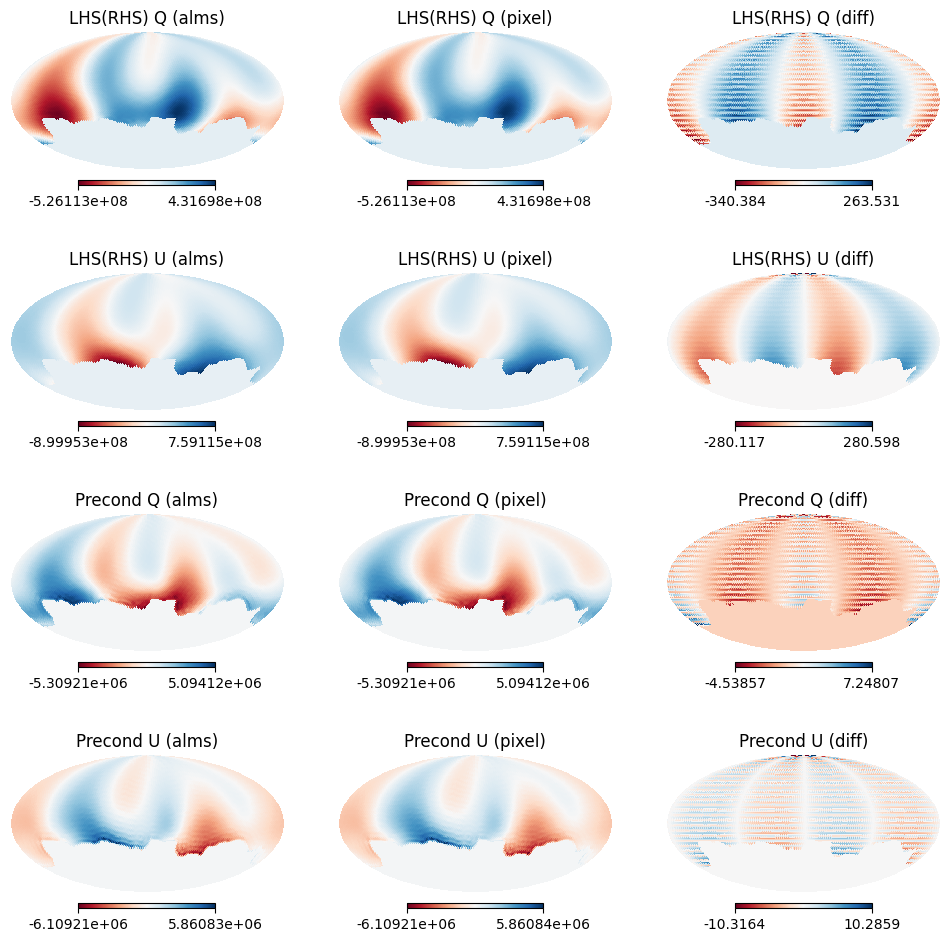

In [32]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12))

def get_maps_from_alms(alms):
    return hp.alm2map(
        np.concatenate((np.zeros_like(alms[0,0,:])[np.newaxis,:], alms[0])),
        nside=nside
    )

def plot_row(row_idx, map_alm, map_pix, title_prefix):
    maps = [map_alm, map_pix, map_alm - map_pix]
    titles = ["alms", "pixel", "diff"]

    for j in range(3):
        plt.sca(ax[row_idx, j])
        hp.mollview(
            maps[j],
            title=f"{title_prefix} ({titles[j]})",
            cmap = "RdBu",
            hold=True
        )

# ---------- LHS(RHS) ----------
test_alms = func_left_term_alms(right_member_alms.ravel()).reshape((n_components, nstokes, n_lms))
test_pixel = func_left_term(right_member_WF.ravel() + right_member_fluct.ravel()).reshape((n_components, nstokes, n_pix))*(1-mask)

maps_alm = get_maps_from_alms(test_alms)*(1-mask)

plot_row(0, maps_alm[1], test_pixel[0,0], "LHS(RHS) Q")
plot_row(1, maps_alm[2], test_pixel[0,1], "LHS(RHS) U")


# ---------- Preconditioned ----------
test_alms = precond_func_alms(func_left_term_alms(right_member_alms.ravel())).reshape((n_components, nstokes, n_lms))
test_pixel = precond_func(func_left_term(right_member_WF.ravel() + right_member_fluct.ravel())).reshape((n_components, nstokes, n_pix))*(1-mask)

maps_alm = get_maps_from_alms(test_alms)*(1-mask)

plot_row(2, maps_alm[1], test_pixel[0,0], "Precond Q")
plot_row(3, maps_alm[2], test_pixel[0,1], "Precond U")

In [33]:
testing_almxfl_alms = right_member_alms[0,0,:][np.newaxis, np.newaxis, :]
testing_almxfl_fl = redcom_cov_matrix_sqrt.copy()[:,0,0,0,0][:, np.newaxis, np.newaxis, np.newaxis, np.newaxis]

In [34]:
frequency_almxfl_2D(testing_almxfl_alms, testing_almxfl_fl, lmax = lmax, lmin = lmin)

Array([[[ 0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
          5.42616265e+02+0.j        , ...,  2.50178160e-02+0.0218116j ,
         -3.56546973e-02-0.03497101j,  3.24563891e-02+0.00752837j]]],      dtype=complex128)

In [35]:
hp.almxfl(testing_almxfl_alms[0,0,:], np.concatenate((jnp.array([0,0]),testing_almxfl_fl[:,0,0,0,0])))

array([ 0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
        5.42616265e+02+0.j        , ...,  2.50178160e-02+0.0218116j ,
       -3.56546973e-02-0.03497101j,  3.24563891e-02+0.00752837j],
      shape=(2145,))

In [36]:
np.max(frequency_almxfl_2D(testing_almxfl_alms, testing_almxfl_fl, lmax = lmax, lmin = lmin) - hp.almxfl(testing_almxfl_alms[0,0,:], np.concatenate((jnp.array([0,0]),testing_almxfl_fl[:,0,0,0,0])))), np.min(frequency_almxfl_2D(testing_almxfl_alms, testing_almxfl_fl, lmax = lmax, lmin = lmin) - hp.almxfl(testing_almxfl_alms[0,0,:], np.concatenate((jnp.array([0,0]),testing_almxfl_fl[:,0,0,0,0]))))

(Array(0.+0.j, dtype=complex128), Array(0.+0.j, dtype=complex128))

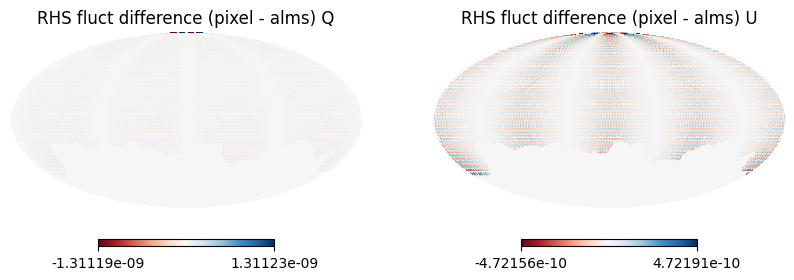

In [37]:
test_rm_fluct = (jax.vmap(ICARUS_obj.get_band_limited_maps)(right_member_1)) + right_member_2
right_member_fluct_alms = jax.vmap(pure_call_map2alm)(np.concatenate((jnp.zeros_like(test_rm_fluct[:, 0][:, None, ...]),test_rm_fluct), axis = 1))[
    :, 3 - nstokes :, ...]
test_rm_fluct_alms = pure_call_alm2map(right_member_fluct_alms[0])[1:]
fig, ax = plt.subplots(1,2, figsize = (10,8))
plt.axes(ax[0])
hp.mollview(test_rm_fluct[0,0]*(1-mask) - test_rm_fluct_alms[0]*(1-mask), cmap = "RdBu", title = "RHS fluct difference (pixel - alms) Q", hold = True)
plt.axes(ax[1])
hp.mollview(test_rm_fluct[0,1]*(1-mask) - test_rm_fluct_alms[1]*(1-mask), cmap = "RdBu", title = "RHS fluct difference (pixel - alms) U", hold = True)

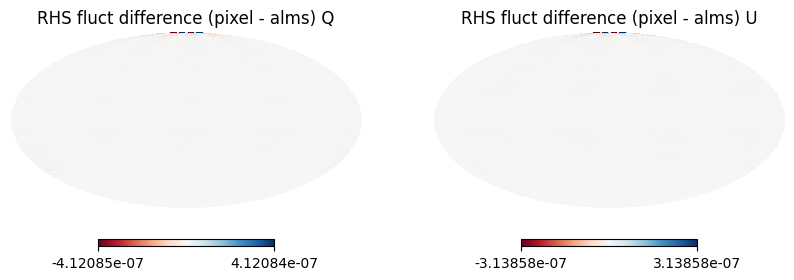

In [38]:
test_rm_WF = right_member_WF
right_member_WF_alms = jax.vmap(pure_call_map2alm)(np.concatenate((jnp.zeros_like(test_rm_WF[:, 0][:, None, ...]),test_rm_WF), axis = 1))[
    :, 3 - nstokes :, ...]
test_rm_WF_alms = pure_call_alm2map(right_member_WF_alms[0])[1:]
fig, ax = plt.subplots(1,2, figsize = (10,8))
plt.axes(ax[0])
hp.mollview(test_rm_WF[0,0]*(1-mask) - test_rm_WF_alms[0]*(1-mask), cmap = "RdBu", title = "RHS fluct difference (pixel - alms) Q", hold = True)
plt.axes(ax[1])
hp.mollview(test_rm_WF[0,1]*(1-mask) - test_rm_WF_alms[1]*(1-mask), cmap = "RdBu", title = "RHS fluct difference (pixel - alms) U", hold = True)